# 🪙 Gold Price Prediction

This project predicts gold prices using machine learning techniques based on historical financial indicators.

## Objective
To build a regression model that can estimate gold prices using features such as oil prices, stock indices, and currency values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Data Collection and Processing

In [2]:
# loading the csv data to Pandas DataFrame
gold_dataset = pd.read_csv("data/gold_price_data.csv")

In [3]:
gold_dataset.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
# print the last 5 rows
gold_dataset.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


## 📊 Dataset Description

The dataset contains historical financial data including:

- **Date** – Observation date  
- **SPX** – S&P 500 index  
- **GLD** – Gold ETF price (target variable)  
- **USO** – Oil prices  
- **SLV** – Silver prices  
- **EUR/USD** – Currency exchange rate  

GLD is used as a proxy for gold price.

In [5]:
gold_dataset.shape

(2290, 6)

In [6]:
gold_dataset.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [7]:
gold_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
gold_dataset.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


Separating the target and the labels

In [9]:
X = gold_dataset.drop(["Date", "GLD"], axis=1)
Y = gold_dataset["GLD"]

The Date column is removed as it is not directly useful for standard regression modeling.

In [10]:
X.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [11]:
print(X.shape)
print(Y.shape)

(2290, 4)
(2290,)


Correlation :
1. Postive Correlation
2. Negative Correlation

In [12]:
gold_dataset = gold_dataset.drop(["Date"],axis=1)

In [13]:
correlation = gold_dataset.corr()

<Axes: >

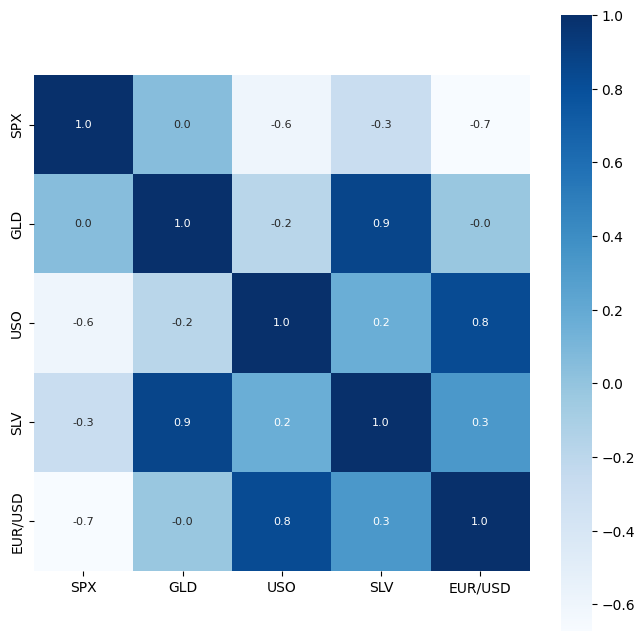

In [14]:
# constructing the heatmap to understand the correlation
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar = True, square = True, fmt=".1f",annot=True,annot_kws={"size":8},cmap = "Blues")

### Observations

- Gold price (GLD) shows strong correlation with silver (SLV)
- Moderate relationship with oil prices (USO)
- Weak or varying correlation with stock index (SPX)

This helps in understanding which features influence gold prices.

In [15]:
# correlation values of GLD
print(correlation["GLD"])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


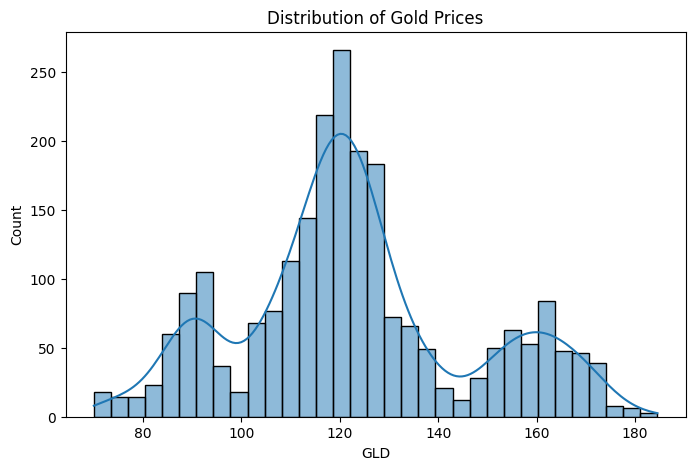

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(gold_dataset["GLD"], kde=True)
plt.title("Distribution of Gold Prices")
plt.show()

## 🔀 Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [17]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

## 🤖 Model Training – Random Forest Regressor

In [18]:
regressor = RandomForestRegressor(n_estimators=100)

In [19]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation


In [20]:
# prediction on test data
test_data_prediction = regressor.predict(X_test)


In [21]:
print(test_data_prediction)

[168.37659872  81.9361     116.08830062 127.65390065 120.65120169
 154.70439745 150.26669916 126.05590047 117.31539886 125.94530082
 116.81490082 172.73640106 141.51579812 167.58169842 115.15340002
 117.79100058 138.68960282 169.93510108 159.89230236 159.66700016
 155.11510003 125.42650013 176.03659907 157.06190341 125.16900042
  93.73679937  77.36230032 120.70900006 119.05869907 167.54549961
  88.27820039 125.19529993  91.03020083 117.65420022 121.09309881
 135.9657001  115.44850131 115.41460087 149.4689998  107.10330104
 104.30540258  87.09429782 126.46620067 117.88989998 153.59019943
 119.58910019 108.40770004 108.15099797  93.18090058 127.28829729
  74.61340062 113.65209912 121.2861001  111.30519941 118.88869896
 120.86739932 159.88770057 168.44520067 146.59699691  85.61579847
  94.35950025  86.70329885  90.63850003 118.85760072 126.43400088
 127.5892999  169.83409971 122.28459971 117.54129877  98.78660094
 168.36710116 143.09229846 132.49590233 121.10330224 120.6037994
 119.751500

In [22]:
test_pred = regressor.predict(X_test)

print("MAE :", mean_absolute_error(Y_test, test_pred))
print("MSE :", mean_squared_error(Y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, test_pred)))
print("R2  :", r2_score(Y_test, test_pred))

MAE : 1.308897224934494
MSE : 5.472162514221526
RMSE: 2.339265379178157
R2  : 0.9896251209704158


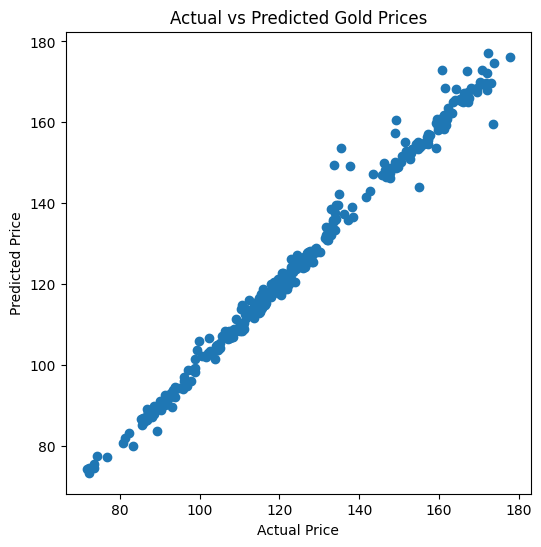

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Gold Prices")
plt.show()

Compare the Actual Prices and Predcited Values in a graph

In [24]:
Y_test = list(Y_test)

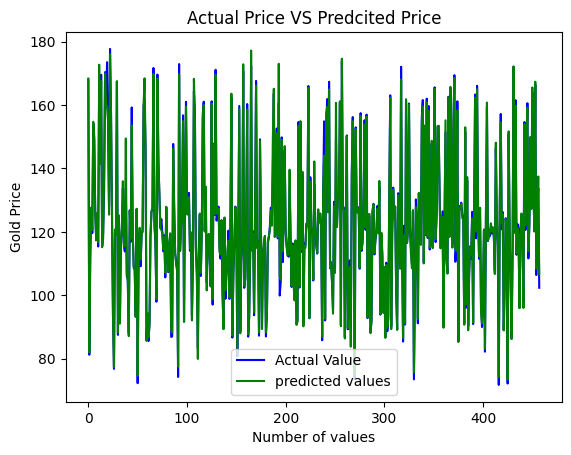

In [25]:
plt.plot(Y_test,color = "blue", label = "Actual Value")
plt.plot(test_data_prediction,color = "green", label = "predicted values")
plt.title("Actual Price VS Predcited Price")
plt.xlabel("Number of values")
plt.ylabel("Gold Price")
plt.legend()
plt.show()

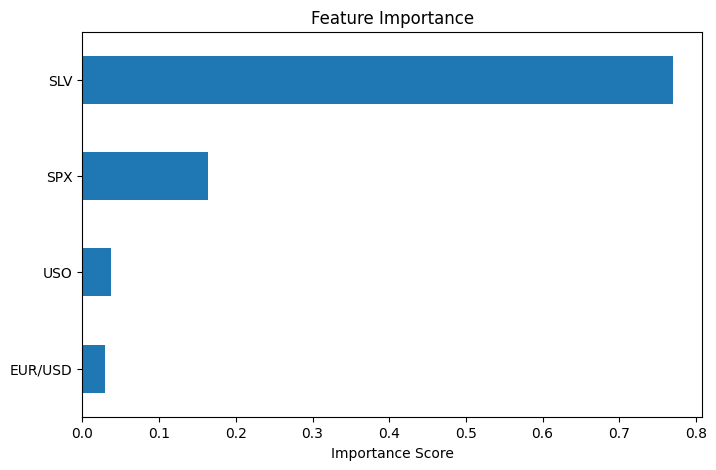

In [26]:
feature_importance = pd.Series(regressor.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [27]:
# input_data = (1447.160034,84.860001,78.470001,15.18)
input_data = (X.iloc[48])

input_data_as_numpy = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)
print(prediction)

[97.42830033]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 🧾 Conclusion

- Historical financial data was used to predict gold prices.
- Random Forest Regressor performed well on the dataset.
- Silver price (SLV) was the most influential feature.
- The model can be extended for real-time financial forecasting.

This project demonstrates the use of machine learning in financial prediction tasks.